In [14]:
# ═══════════════════════════════════════════════════════════════
#  Embryo Stage Classification  ·  CNN + LSTM Pipeline
# ═══════════════════════════════════════════════════════════════

# --- Kaggle / CUDA setup MUST happen before importing torch ---
import os
os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_MODULE_LOADING", "LAZY")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("TORCH_CUDNN_V8_API_DISABLED", "1")

import re, csv, math, random, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from collections import Counter
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# --- CUDA stability flags ---
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

# On Kaggle/P100, cuDNN LSTM flattening can crash with:
#   AcceleratorError: CUDA error: no kernel image is available for execution on the device
# These patches keep the model on CUDA while skipping the problematic flatten step.
try:
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.enabled = False
        torch.backends.cudnn.benchmark = False
except Exception:
    pass

def _get_device() -> torch.device:
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        cap = torch.cuda.get_device_capability(0)
        print(f"[INFO] CUDA detected — {name} (compute {cap[0]}.{cap[1]})")
        return torch.device("cuda")
    print("[INFO] No CUDA detected — using CPU.")
    return torch.device("cpu")

DEVICE = _get_device()
print(f"[INFO] Active device: {DEVICE}")
try:
    print(f"[INFO] cuDNN enabled: {torch.backends.cudnn.enabled}")
except Exception:
    pass

def debug_cuda_state(model: torch.nn.Module | None = None, loader: DataLoader | None = None):
    print(f"[CHECK] torch.cuda.is_available(): {torch.cuda.is_available()}")
    print(f"[CHECK] Active device: {DEVICE}")
    if torch.cuda.is_available():
        print(f"[CHECK] GPU: {torch.cuda.get_device_name(0)}")
    if model is not None:
        try:
            print(f"[CHECK] Model param device: {next(model.parameters()).device}")
        except StopIteration:
            print("[CHECK] Model has no parameters.")
    if loader is not None:
        try:
            batch = next(iter(loader))
            frames, labels = batch
            print(f"[CHECK] Loader batch device before move: {frames.device}, {labels.device}")
        except Exception as e:
            print(f"[CHECK] Loader probe failed: {e}")


[INFO] CUDA detected — Tesla T4 (compute 7.5)
[INFO] Active device: cuda
[INFO] cuDNN enabled: False


In [15]:
"""
setup_env.py  —  Cell 0. Must be the very first cell. No restart needed.
=========================================================================
Strategy
--------
Check the installed torch version using importlib.metadata (zero imports
of torch itself). If it's wrong, reinstall BEFORE torch is ever imported
into the process. This way Kaggle "Save and Run" works in one shot.

Required cell order in your notebook
-------------------------------------
  Cell 0 : exec(open("setup_env.py").read())   ← this file
  Cell 1 : from embryo_train import ...         ← first torch import
  Cell 2 : loaders = make_dataloaders(...)
  Cell 3 : train_all_models(loaders, ...)

DO NOT import torch before Cell 0 completes.
"""

import subprocess
import sys


# ── 1. Read installed versions WITHOUT importing torch ────────────────────────

def _installed_version(pkg: str) -> str:
    """Return installed version string, or '' if not found."""
    try:
        from importlib.metadata import version
        return version(pkg)
    except Exception:
        return ""


WANT_TORCH       = "2.5.1"
WANT_TORCHVISION = "0.20.1"
INDEX_URL        = "https://download.pytorch.org/whl/cu121"


def _version_ok() -> bool:
    tv = _installed_version("torch")
    tv2 = _installed_version("torchvision")
    return tv.startswith(WANT_TORCH) and tv2.startswith(WANT_TORCHVISION)


# ── 2. Install if wrong version (before any torch import) ─────────────────────

def ensure_compatible_torch():
    current = _installed_version("torch")

    if _version_ok():
        print(f"[OK] torch={_installed_version('torch')}  "
              f"torchvision={_installed_version('torchvision')}")
        print("[OK] Correct version already installed — no action needed.\n")
        return

    print(f"[INFO] Installed torch={current or 'not found'}  "
          f"(need {WANT_TORCH}+cu121 for P100 GPU)")
    print(f"[INFO] Installing torch=={WANT_TORCH} + "
          f"torchvision=={WANT_TORCHVISION} …")

    result = subprocess.run([
        sys.executable, "-m", "pip", "install",
        f"torch=={WANT_TORCH}",
        f"torchvision=={WANT_TORCHVISION}",
        "--index-url", INDEX_URL,
        "--force-reinstall",
        "--no-deps",
        "-q",
    ], capture_output=True, text=True)

    if result.returncode != 0:
        print("[ERROR] pip install failed:")
        print(result.stderr[-2000:])
        raise RuntimeError("Could not install compatible PyTorch. "
                           "Check your internet connection.")

    # Verify the files on disk changed
    if not _version_ok():
        print("[WARN] pip reported success but version still wrong.")
        print("       Try: Runtime > Restart and run again.")
    else:
        print(f"[OK] Installed torch={_installed_version('torch')}  "
              f"torchvision={_installed_version('torchvision')}")

    # Flush pip's cached dist-info so subsequent imports pick up new version
    import importlib
    import importlib.metadata
    try:
        importlib.invalidate_caches()
    except Exception:
        pass

    print("[OK] Install complete — no restart needed for Save & Run.\n")


# ── 3. Post-install GPU smoke test (only after install/confirm) ───────────────

def validate():
    """Run after ensure_compatible_torch(). First torch import happens here."""
    import torch
    import torch.nn as nn
    from torchvision import models

    print(f"[CHECK] torch={torch.__version__}  "
          f"torchvision={__import__('torchvision').__version__}")

    if not torch.cuda.is_available():
        print("[WARN] CUDA not available — will train on CPU (slow).")
        return

    # Strict GPU test: conv2d + hardtanh (the exact ops that fail on P100+cu128)
    try:
        x    = torch.randn(1, 3, 16, 16).cuda()
        conv = nn.Conv2d(3, 8, 3, padding=1).cuda()
        with torch.no_grad():
            _ = nn.Hardtanh()(conv(x))
        print(f"[OK] GPU conv2d test passed on {torch.cuda.get_device_name(0)}")
    except Exception as e:
        print(f"[ERROR] GPU conv2d test FAILED: {e}")
        print("        torch version on disk is correct but the OLD version")
        print("        is still loaded in memory.")
        print("        → This only happens when torch was imported before Cell 0.")
        print("        → Fix: Runtime > Restart Session, then re-run from Cell 0.")
        raise SystemExit("Please restart the kernel and re-run from Cell 0.")

    # Full model forward pass test
    print("[CHECK] Testing all model families on GPU …")
    for name, build, inp_size in [
        ("MobileNetV1 (custom)", None,                            224),
        ("MobileNetV2",  models.mobilenet_v2,                    224),
        ("VGG16-BN",     models.vgg16_bn,                        224),
        ("VGG19-BN",     models.vgg19_bn,                        224),
        ("InceptionV3",  models.inception_v3,                    299),
    ]:
        try:
            if build is None:
                # MobileNetV1 — test our custom implementation if available
                try:
                    sys.path.insert(0, "/kaggle/working")
                    from embryo_models import MobileNetV1
                    m = MobileNetV1().cuda().eval()
                except ImportError:
                    print(f"  [SKIP] {name}: embryo_models.py not on path yet "
                          f"— will work fine when embryo_train imports it.")
                    continue
            elif name == "InceptionV3":
                m = build(weights=None, aux_logits=False).cuda().eval()
            else:
                m = build(weights=None).cuda().eval()

            x_test = torch.randn(2, 3, inp_size, inp_size).cuda()
            with torch.no_grad():
                _ = m(x_test)
            print(f"  [OK] {name}")
            del m
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"  [FAIL] {name}: {e}")

    print()
    print("=" * 50)
    print("  Environment summary")
    print("=" * 50)
    print(f"  torch       : {torch.__version__}")
    print(f"  torchvision : {__import__('torchvision').__version__}")
    print(f"  CUDA        : {torch.version.cuda}")
    print(f"  GPU         : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  VRAM        : {vram:.1f} GB")
    print("=" * 50)
    print("\n[READY] Safe to proceed.\n")


# ── Run ───────────────────────────────────────────────────────────────────────
ensure_compatible_torch()   # no torch import — safe to call unconditionally
validate()                  # first torch import happens here

[OK] torch=2.5.1+cu121  torchvision=0.20.1+cu121
[OK] Correct version already installed — no action needed.

[CHECK] torch=2.5.1+cu121  torchvision=0.20.1+cu121
[OK] GPU conv2d test passed on Tesla T4
[CHECK] Testing all model families on GPU …
  [SKIP] MobileNetV1 (custom): embryo_models.py not on path yet — will work fine when embryo_train imports it.
  [OK] MobileNetV2
  [OK] VGG16-BN
  [OK] VGG19-BN
  [OK] InceptionV3

  Environment summary
  torch       : 2.5.1+cu121
  torchvision : 0.20.1+cu121
  CUDA        : 12.1
  GPU         : Tesla T4
  VRAM        : 15.6 GB

[READY] Safe to proceed.



## 1 · Stage Labels & Transforms

In [16]:
# ── 16 embryo stage labels ────────────────────────────────────────────────
STAGES = [
    "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+",
    "tB", "tEB", "tHB", "tM", "tPB2", "tPNa", "tPNf", "tSB",
]
LABEL2IDX: Dict[str, int] = {s: i for i, s in enumerate(STAGES)}
IDX2LABEL: Dict[int, str] = {i: s for i, s in enumerate(STAGES)}
NUM_CLASSES = len(STAGES)

# ── Colour palette for plots ──────────────────────────────────────────────
PALETTE = plt.cm.tab20.colors[:NUM_CLASSES]

# ── ImageNet normalisation ────────────────────────────────────────────────
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(_MEAN, _STD),
])

print("Stages:", STAGES)
print("NUM_CLASSES:", NUM_CLASSES)


Stages: ['t2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tB', 'tEB', 'tHB', 'tM', 'tPB2', 'tPNa', 'tPNf', 'tSB']
NUM_CLASSES: 16


## 2 · Dataset Paths

In [17]:
DATASET_ROOT      = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset'
ANNOTATIONS_ROOT  = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations'

# Quick sanity check
print("Dataset root exists :", Path(DATASET_ROOT).exists())
print("Annotations root exists:", Path(ANNOTATIONS_ROOT).exists())
if Path(DATASET_ROOT).exists():
    dirs = [d.name for d in sorted(Path(DATASET_ROOT).iterdir()) if d.is_dir()]
    print(f"  Found {len(dirs)} video folders, first few: {dirs[:5]}")
if Path(ANNOTATIONS_ROOT).exists():
    csvs = list(Path(ANNOTATIONS_ROOT).glob("*.csv"))
    print(f"  Found {len(csvs)} CSV annotation files")


Dataset root exists : True
Annotations root exists: True
  Found 704 video folders, first few: ['AA83-7', 'AAL839-6', 'AB028-6', 'AB91-1', 'AC264-1']
  Found 704 CSV annotation files


## 3 · CSV Parser & Frame-Number Helper

In [18]:
def _frame_number(filename: str) -> Optional[int]:
    """Extract the last integer from a filename stem as the frame number.
    e.g. 'D2016_S1782_RUN042.jpeg' → 42
    """
    nums = re.findall(r"\d+", Path(filename).stem)
    return int(nums[-1]) if nums else None


def _parse_csv(csv_path: Path) -> Dict[int, int]:
    """
    Parse an annotation CSV into {frame_number: label_idx}.

    Handles both formats automatically:
      3-column : stage, start_frame, end_frame        (e.g. tPNa,25,88)
      4-column : index, stage, start_frame, end_frame (e.g. 0,tPNa,25,88)

    FIX vs original: the original always read row[0] as the stage.
    If the CSV has a leading row-index column ("0","1","2"…), every row
    was silently skipped because "0" is not a valid stage name, resulting
    in zero samples being loaded.
    """
    frame_to_label: Dict[int, int] = {}
    with open(csv_path, newline="", encoding="utf-8-sig") as f:
        for row in csv.reader(f):
            row = [c.strip() for c in row]
            if not row:
                continue
            # Auto-detect 4-column format: first field is a plain integer
            if len(row) >= 4 and row[0].lstrip("-").isdigit():
                stage_col, start_col, end_col = 1, 2, 3
            elif len(row) >= 3:
                stage_col, start_col, end_col = 0, 1, 2
            else:
                continue
            stage = row[stage_col]
            if stage not in LABEL2IDX:
                continue
            try:
                start, end = int(row[start_col]), int(row[end_col])
            except ValueError:
                continue
            label = LABEL2IDX[stage]
            for fn in range(start, end + 1):
                frame_to_label[fn] = label
    return frame_to_label


# ── Quick CSV test ────────────────────────────────────────────────────────
if Path(ANNOTATIONS_ROOT).exists():
    sample_csv = next(Path(ANNOTATIONS_ROOT).glob("*.csv"), None)
    if sample_csv:
        fm = _parse_csv(sample_csv)
        print(f"Parsed '{sample_csv.name}': {len(fm)} annotated frames")
        sample_items = list(fm.items())[:4]
        print("  First 4 entries:", [(f, IDX2LABEL[l]) for f, l in sample_items])


Parsed 'BC750-7_phases.csv': 468 annotated frames
  First 4 entries: [(6, 'tPB2'), (7, 'tPB2'), (8, 'tPB2'), (9, 'tPB2')]


## 4 · Build Sliding-Window Sequences

In [19]:
def build_sequence_samples(
    dataset_root:     str,
    annotations_root: str,
    seq_len:          int = 16,
    stride:           int = 8,
) -> List[Tuple[List[Path], List[int], str]]:
    """
    Returns list of (frame_paths, labels, video_id) tuples.
    Each tuple is one sliding-window sequence of length seq_len.
    Sequences never cross video boundaries.
    """
    dataset_root     = Path(dataset_root)
    annotations_root = Path(annotations_root)

    all_sequences = []
    skipped_csv   = 0
    skipped_short = 0
    matched_vids  = 0

    for video_dir in tqdm(
        sorted(d for d in dataset_root.iterdir() if d.is_dir()),
        desc="Scanning videos",
        leave=False,
    ):
        vid      = video_dir.name
        csv_path = annotations_root / f"{vid}_phases.csv"
        if not csv_path.exists():
            skipped_csv += 1
            continue

        frame_to_label = _parse_csv(csv_path)

        frames = sorted(
            list(video_dir.glob("*.jpg")) + list(video_dir.glob("*.jpeg")),
            key=lambda p: _frame_number(p.name) or 0,
        )

        # Keep only frames that have an annotation
        valid = [
            (p, frame_to_label[_frame_number(p.name)])
            for p in frames
            if _frame_number(p.name) is not None
            and _frame_number(p.name) in frame_to_label
        ]

        if len(valid) < seq_len:
            skipped_short += 1
            continue

        for start in range(0, len(valid) - seq_len + 1, stride):
            window = valid[start: start + seq_len]
            all_sequences.append((
                [w[0] for w in window],
                [w[1] for w in window],
                vid,
            ))
        matched_vids += 1

    print(f"[INFO] Built {len(all_sequences):,} sequences "
          f"(seq_len={seq_len}, stride={stride}) across {matched_vids} videos.")
    if skipped_csv:
        print(f"       Skipped {skipped_csv} folder(s) — no matching CSV found.")
    if skipped_short:
        print(f"       Skipped {skipped_short} video(s) — fewer frames than seq_len.")
    return all_sequences


def split_sequences_by_video(
    sequences:  List,
    val_ratio:  float = 0.15,
    test_ratio: float = 0.15,
    seed:       int   = 42,
) -> Tuple[List, List, List]:
    """Video-level split so no video appears in more than one split."""
    random.seed(seed)
    vids = sorted({s[2] for s in sequences})
    random.shuffle(vids)
    n      = len(vids)
    n_val  = max(1, math.ceil(n * val_ratio))
    n_test = max(1, math.ceil(n * test_ratio))
    val_ids   = set(vids[:n_val])
    test_ids  = set(vids[n_val: n_val + n_test])
    train_ids = set(vids[n_val + n_test:])
    train = [s for s in sequences if s[2] in train_ids]
    val   = [s for s in sequences if s[2] in val_ids]
    test  = [s for s in sequences if s[2] in test_ids]
    print(f"[INFO] Split → "
          f"train: {len(train):,} ({len(train_ids)} videos) | "
          f"val: {len(val):,} ({len(val_ids)} videos) | "
          f"test: {len(test):,} ({len(test_ids)} videos)")
    return train, val, test


## 5 · EmbryoSequenceDataset

In [20]:
class EmbryoSequenceDataset(Dataset):
    """
    Returns fixed-length consecutive-frame sequences.

    __getitem__ → (frames_tensor, labels_tensor)
        frames_tensor : (seq_len, 3, 224, 224)  float32
        labels_tensor : (seq_len,)               int64

    FIX vs original:
      1. On a corrupt/missing frame, the original jumped to a DIFFERENT
         sequence (real_idx shifted), producing silently wrong (frame, label)
         pairs.  Now we substitute a black frame for the bad file and keep
         the correct labels.
      2. torch.stack([]) raised RuntimeError when all frames failed.
         A safe all-zeros fallback is returned instead.
      3. sequence_weights() used cw[labels] where labels is List[int],
         which fails with IndexError in many torch versions.
         Fixed to use torch.tensor(labels) for indexing.
    """

    def __init__(
        self,
        sequences: List[Tuple[List[Path], List[int], str]],
        transform=None,
    ):
        self.sequences = sequences
        self.transform = transform
        self._blank    = torch.zeros(3, 224, 224)  # fallback for corrupt frames

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx: int):
        frame_paths, labels, _ = self.sequences[idx]
        loaded = []
        for p in frame_paths:
            try:
                img = Image.open(p).convert("RGB")
                if self.transform:
                    img = self.transform(img)
                loaded.append(img)
            except Exception:
                # Substitute a black frame — label is kept unchanged
                loaded.append(self._blank.clone())

        if not loaded:          # safety guard: all frames failed
            loaded = [self._blank.clone() for _ in frame_paths]

        frames_tensor = torch.stack(loaded)                       # (T, 3, H, W)
        labels_tensor = torch.tensor(labels, dtype=torch.long)   # (T,)
        return frames_tensor, labels_tensor

    # ── Class statistics ─────────────────────────────────────────────────

    def class_counts(self) -> Counter:
        """Frame-level label counts across all sequences."""
        c = Counter()
        for _, labels, _ in self.sequences:
            c.update(labels)
        return c

    def class_weights(self) -> torch.Tensor:
        counts  = self.class_counts()
        weights = torch.zeros(NUM_CLASSES)
        for cls, cnt in counts.items():
            if cnt > 0:
                weights[cls] = 1.0 / cnt
        total = weights.sum()
        return (weights / total * NUM_CLASSES) if total > 0 else weights

    def sequence_weights(self) -> torch.Tensor:
        """
        Per-sequence weight = mean of its frame-level class weights.
        Used by WeightedRandomSampler to oversample rare-stage sequences.
        """
        cw = self.class_weights()
        sw = []
        for _, labels, _ in self.sequences:
            label_tensor = torch.tensor(labels, dtype=torch.long)  # FIX: was cw[labels] (List)
            sw.append(cw[label_tensor].mean().item())
        return torch.tensor(sw, dtype=torch.float)


## 6 · DataLoader Factory

In [21]:

def make_sequence_dataloaders(
    dataset_root:     str,
    annotations_root: str,
    seq_len:          int   = 16,
    stride:           int   = 8,
    batch_size:       int   = 8,
    num_workers:      int   = 2,
    val_ratio:        float = 0.15,
    test_ratio:       float = 0.15,
    oversample_train: bool  = True,
    seed:             int   = 42,
) -> Dict[str, DataLoader]:

    seqs = build_sequence_samples(
        dataset_root, annotations_root, seq_len=seq_len, stride=stride
    )
    if not seqs:
        raise RuntimeError(
            "No sequences found. Check that DATASET_ROOT and ANNOTATIONS_ROOT "
            "are correct and that CSV files use the expected naming pattern "
            "'{video_name}_phases.csv'."
        )

    train_s, val_s, test_s = split_sequences_by_video(
        seqs, val_ratio=val_ratio, test_ratio=test_ratio, seed=seed
    )

    train_ds = EmbryoSequenceDataset(train_s, transform=TRAIN_TRANSFORM)
    val_ds   = EmbryoSequenceDataset(val_s,   transform=EVAL_TRANSFORM)
    test_ds  = EmbryoSequenceDataset(test_s,  transform=EVAL_TRANSFORM)

    print("\n[INFO] Train class distribution (frame-level):")
    counts = train_ds.class_counts()
    for i, name in IDX2LABEL.items():
        bar = "█" * min(40, counts.get(i, 0) // max(1, max(counts.values()) // 40))
        print(f"  {name:>6}: {counts.get(i, 0):6,}  {bar}")

    if oversample_train:
        sampler = WeightedRandomSampler(
            train_ds.sequence_weights(), len(train_ds), replacement=True
        )
        train_shuffle = False
    else:
        sampler = None
        train_shuffle = True

    pin = DEVICE.type == "cuda"
    pers = num_workers > 0
    loader_kwargs = dict(
        num_workers=num_workers,
        pin_memory=pin,
        persistent_workers=pers,
    )
    if num_workers > 0:
        loader_kwargs["prefetch_factor"] = 2

    loaders = {
        "train": DataLoader(
            train_ds,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=train_shuffle,
            **loader_kwargs,
        ),
        "val": DataLoader(
            val_ds,
            batch_size=batch_size,
            shuffle=False,
            **loader_kwargs,
        ),
        "test": DataLoader(
            test_ds,
            batch_size=batch_size,
            shuffle=False,
            **loader_kwargs,
        ),
    }
    print(f"\n[INFO] DataLoaders ready — "
          f"train: {len(loaders['train'])} batches | "
          f"val: {len(loaders['val'])} | "
          f"test: {len(loaders['test'])}\n")
    return loaders, train_ds, val_ds, test_ds


## 7 · Display: Class Distribution

In [22]:
def plot_class_distribution(train_ds, val_ds, test_ds):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
    for ax, ds, title in zip(axes, [train_ds, val_ds, test_ds],
                              ["Train", "Val", "Test"]):
        counts = ds.class_counts()
        names  = [IDX2LABEL[i] for i in range(NUM_CLASSES)]
        values = [counts.get(i, 0) for i in range(NUM_CLASSES)]
        bars = ax.bar(names, values, color=PALETTE, edgecolor="black", linewidth=0.5)
        ax.set_title(f"{title} — {sum(values):,} frames", fontsize=13, fontweight="bold")
        ax.set_xlabel("Embryo Stage")
        ax.set_ylabel("Frame Count")
        ax.tick_params(axis="x", rotation=45)
        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                        f"{val:,}", ha="center", va="bottom", fontsize=7)
    plt.suptitle("Frame-Level Class Distribution per Split", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → class_distribution.png")


## 8 · Model: EfficientNet-B0 Backbone + LSTM

In [23]:
class EmbryoCNNLSTM(nn.Module):
    """
    Frame features extracted by a frozen EfficientNet-B0 backbone,
    then modelled temporally by an LSTM.

    Input  : (batch, seq_len, 3, 224, 224)
    Output : (batch, seq_len, NUM_CLASSES)   — per-frame logits
    """

    def __init__(
        self,
        num_classes:      int   = NUM_CLASSES,
        hidden_size:      int   = 256,
        num_layers:       int   = 2,
        dropout:          float = 0.3,
        freeze_backbone:  bool  = True,
    ):
        super().__init__()

        # ── CNN backbone ──────────────────────────────────────────────────
        backbone = models.efficientnet_b0(weights=None)
        
        # load manually (safe)
        state_dict = torch.hub.load_state_dict_from_url(
            "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth",
            map_location="cpu"
        )
        
        backbone.load_state_dict(state_dict, strict=False)
        feature_dim  = backbone.classifier[1].in_features  # 1280
        backbone.classifier = nn.Identity()
        self.backbone = backbone

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # ── LSTM ──────────────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size  = feature_dim,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
            bidirectional = False,
        )
        # Kaggle/P100-safe: avoid the cuDNN flatten path that can trigger
        # CUDA kernel-image errors on some notebook images.
        self.lstm.flatten_parameters = lambda: None
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, T, C, H, W)
        B, T, C, H, W = x.shape
        feat = self.backbone(x.view(B * T, C, H, W))  # (B*T, feature_dim)
        feat = feat.view(B, T, -1)                     # (B,  T, feature_dim)
        out, _ = self.lstm(feat)                       # (B,  T, hidden_size)
        logits  = self.classifier(self.dropout(out))   # (B,  T, num_classes)
        return logits

    def unfreeze_backbone(self):
        """Call after initial training to fine-tune the backbone too."""
        for p in self.backbone.parameters():
            p.requires_grad = True
        print("[INFO] Backbone unfrozen for fine-tuning.")


# ── Architecture sanity check (CPU-only; training still uses DEVICE) ──
_probe_device = torch.device("cpu")
_dummy_model  = EmbryoCNNLSTM(hidden_size=128, num_layers=1).to(_probe_device)
_dummy_input  = torch.zeros(2, 4, 3, 224, 224).to(_probe_device)
with torch.no_grad():
    _out = _dummy_model(_dummy_input)
print(f"[INFO] Model output shape: {_out.shape}  (expected: 2 x 4 x {NUM_CLASSES})")
del _dummy_model, _dummy_input, _out, _probe_device
print("[INFO] Architecture OK — model will train on:", DEVICE)


[INFO] Model output shape: torch.Size([2, 4, 16])  (expected: 2 x 4 x 16)
[INFO] Architecture OK — model will train on: cuda


In [24]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.5.1+cu121
0.20.1+cu121


## 9 · Training & Evaluation Utilities

In [25]:

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    first_batch = True

    for frames, labels in tqdm(loader, desc="Training", leave=False):
        frames = frames.to(device, non_blocking=(device.type == "cuda"))
        labels = labels.to(device, non_blocking=(device.type == "cuda"))

        if first_batch:
            print(f"[TRAIN] frames device = {frames.device}, labels device = {labels.device}")
            print(f"[TRAIN] model device = {next(model.parameters()).device}")
            first_batch = False

        optimizer.zero_grad(set_to_none=True)

        use_amp = (scaler is not None) and (device.type == "cuda")
        if use_amp:
            with torch.cuda.amp.autocast():
                logits = model(frames)
                loss = criterion(logits.view(-1, NUM_CLASSES), labels.view(-1))
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(frames)
            loss = criterion(logits.view(-1, NUM_CLASSES), labels.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        total_loss += loss.item() * labels.numel()
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.numel()

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    first_batch = True

    for frames, labels in tqdm(loader, desc="Evaluating", leave=False):
        frames = frames.to(device, non_blocking=(device.type == "cuda"))
        labels = labels.to(device, non_blocking=(device.type == "cuda"))

        if first_batch:
            print(f"[EVAL] frames device = {frames.device}, labels device = {labels.device}")
            print(f"[EVAL] model device = {next(model.parameters()).device}")
            first_batch = False

        logits = model(frames)
        loss = criterion(logits.view(-1, NUM_CLASSES), labels.view(-1))
        total_loss += loss.item() * labels.numel()
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.numel()
        all_preds.extend(preds.view(-1).cpu().tolist())
        all_labels.extend(labels.view(-1).cpu().tolist())

    return total_loss / total, correct / total, all_preds, all_labels


def train_one_config(
    config_name: str,
    loaders:     Dict[str, DataLoader],
    hidden_size: int   = 256,
    num_layers:  int   = 2,
    dropout:     float = 0.3,
    lr:          float = 1e-3,
    num_epochs:  int   = 15,
    device:      torch.device = DEVICE,
) -> Tuple[dict, list, list]:
    """Train a single CNN+LSTM config and return history."""
    print(f"\n{'='*60}")
    print(f"  Config: {config_name}  (hidden={hidden_size}, layers={num_layers})")
    print(f"{'='*60}")
    print(f"[INFO] Training on device: {device}")

    model = EmbryoCNNLSTM(
        hidden_size=hidden_size, num_layers=num_layers, dropout=dropout
    ).to(device)

    counts = loaders["train"].dataset.class_counts()
    freq = torch.tensor([counts.get(i, 1) for i in range(NUM_CLASSES)], dtype=torch.float)
    class_w = (1.0 / freq)
    class_w = (class_w / class_w.sum() * NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_w)

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    debug_cuda_state(model=model, loader=loaders["train"])

    ckpt_path = Path(f"{config_name}_checkpoint.pth")
    start_epoch = 1
    best_val_acc = -1.0
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    if ckpt_path.exists():
        checkpoint = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        if checkpoint.get("scaler_state_dict") is not None:
            scaler.load_state_dict(checkpoint["scaler_state_dict"])
        best_val_acc = checkpoint.get("best_val_acc", best_val_acc)
        best_state = checkpoint.get("best_state", best_state)
        history = checkpoint.get("history", history)
        start_epoch = checkpoint.get("epoch", 0) + 1
        print(f"[INFO] Resumed from checkpoint: {ckpt_path} (starting at epoch {start_epoch})")

    for epoch in tqdm(range(start_epoch, num_epochs + 1), desc=config_name):
        tr_loss, tr_acc = train_one_epoch(
            model, loaders["train"], optimizer, criterion, device, scaler=scaler
        )
        va_loss, va_acc, va_preds, va_labels = evaluate(model, loaders["val"], criterion, device)
        scheduler.step()
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
            va_labels, va_preds, average="macro", zero_division=0
        )

        print(f"  Epoch {epoch:02d}/{num_epochs}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  "
              f"val_loss={va_loss:.4f}  val_acc={va_acc:.3f}  "
              f"val_precision={val_precision:.3f}  val_recall={val_recall:.3f}  val_f1={val_f1:.3f}")

        if va_acc >= best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
            "best_val_acc": best_val_acc,
            "best_state": best_state,
            "history": history,
        }, ckpt_path)
        print(f"  ✓ Saved checkpoint: {ckpt_path}")

    model.load_state_dict(best_state)
    te_loss, te_acc, te_preds, te_labels = evaluate(model, loaders["test"], criterion, device)
    print(f"  ✓ Best val acc: {best_val_acc:.3f}  |  Test acc: {te_acc:.3f}")

    result = {
        "config":   config_name,
        "hidden":   hidden_size,
        "layers":   num_layers,
        "best_val": round(best_val_acc, 4),
        "test_acc": round(te_acc, 4),
        "test_loss": round(te_loss, 4),
    }
    return result, history, (te_preds, te_labels), model


def train_all_lstm_configs(
    loaders:    Dict[str, DataLoader],
    num_epochs: int = 15,
) -> pd.DataFrame:
    configs = [
        {"name": "LSTM-128-1L", "hidden_size": 128, "num_layers": 1, "dropout": 0.2},
        {"name": "LSTM-256-2L", "hidden_size": 256, "num_layers": 2, "dropout": 0.3},
        {"name": "LSTM-512-2L", "hidden_size": 512, "num_layers": 2, "dropout": 0.4},
    ]

    all_results = []
    all_histories = {}
    best_model = None
    best_preds = None
    best_score = -1.0

    for cfg in tqdm(configs, desc="Configs"):
        result, history, preds_labels, model = train_one_config(
            config_name=cfg["name"],
            loaders=loaders,
            hidden_size=cfg["hidden_size"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            num_epochs=num_epochs,
        )
        all_results.append(result)
        all_histories[cfg["name"]] = history

        if result["best_val"] > best_score:
            best_score = result["best_val"]
            best_model = model
            best_preds = preds_labels

    df = pd.DataFrame(all_results).sort_values("best_val", ascending=False).reset_index(drop=True)
    print("\n[RESULTS]")
    print(df.to_string(index=False))

    df.to_csv("lstm_config_results.csv", index=False)
    if best_model is not None:
        torch.save(best_model.state_dict(), "best_embryo_model.pth")
        print("\nSaved → lstm_config_results.csv, best_embryo_model.pth")
    else:
        print("\nSaved → lstm_config_results.csv")

    return df, all_histories, best_preds


## 10 · Build DataLoaders & Run Training

Scanning videos:   0%|          | 0/704 [00:00<?, ?it/s]

[INFO] Built 36,168 sequences (seq_len=16, stride=8) across 704 videos.
[INFO] Split → train: 25,363 (492 videos) | val: 5,519 (106 videos) | test: 5,286 (106 videos)

[INFO] Train class distribution (frame-level):
      t2: 40,487  ██████████████████████
      t3:  7,520  ████
      t4: 40,267  ██████████████████████
      t5: 11,610  ██████
      t6: 11,170  ██████
      t7: 15,536  ████████
      t8: 45,402  █████████████████████████
     t9+: 71,356  ████████████████████████████████████████
      tB: 13,965  ███████
     tEB: 24,011  █████████████
     tHB:    136  
      tM: 24,103  █████████████
    tPB2:  8,559  ████
    tPNa: 59,431  █████████████████████████████████
    tPNf:  9,131  █████
     tSB: 23,124  ████████████

[INFO] DataLoaders ready — train: 3171 batches | val: 690 | test: 661



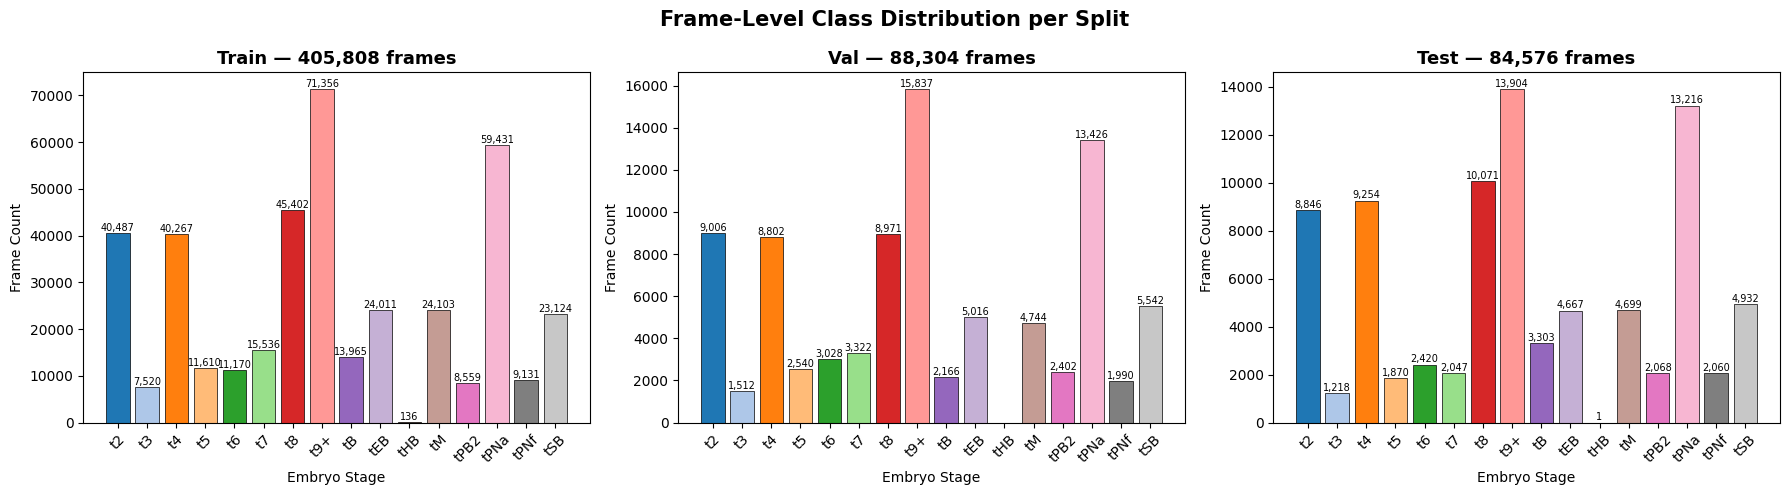

Saved → class_distribution.png


Configs:   0%|          | 0/3 [00:00<?, ?it/s]


  Config: LSTM-128-1L  (hidden=128, layers=1)
[INFO] Training on device: cuda
[CHECK] torch.cuda.is_available(): True
[CHECK] Active device: cuda
[CHECK] GPU: Tesla T4
[CHECK] Model param device: cuda:0
[CHECK] Loader batch device before move: cpu, cpu


LSTM-128-1L:   0%|          | 0/15 [00:00<?, ?it/s]

Training:   0%|          | 0/3171 [00:02<?, ?it/s]

...

[TRAIN] frames device = cuda:0, labels device = cuda:0
[TRAIN] model device = cuda:0


Evaluating:   0%|          | 0/690 [00:00<?, ?it/s]

[EVAL] frames device = cuda:0, labels device = cuda:0
[EVAL] model device = cuda:0
  Epoch 02/15  train_loss=1.0334  train_acc=0.337  val_loss=2.2241  val_acc=0.155  val_precision=0.281  val_recall=0.242  val_f1=0.141
  ✓ Saved checkpoint: LSTM-128-1L_checkpoint.pth


Training:   0%|          | 0/3171 [00:00<?, ?it/s]

[TRAIN] frames device = cuda:0, labels device = cuda:0
[TRAIN] model device = cuda:0


In [ ]:
seq_loaders, train_ds, val_ds, test_ds = make_sequence_dataloaders(
    DATASET_ROOT, ANNOTATIONS_ROOT,
    seq_len=16, stride=8, batch_size=8, num_workers=4,
)

# Display class distribution before training
plot_class_distribution(train_ds, val_ds, test_ds)

results_df, histories, best_preds = train_all_lstm_configs(
    seq_loaders, num_epochs=15
)

print("\n=== Config Comparison ===")
display(results_df)


## 11 · Display: Training Curves

In [ ]:
def plot_training_curves(histories: dict):
    n = len(histories)
    fig, axes = plt.subplots(2, n, figsize=(6 * n, 10))
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (name, h) in enumerate(histories.items()):
        epochs = range(1, len(h["train_loss"]) + 1)

        # Loss
        axes[0, col].plot(epochs, h["train_loss"], label="Train", marker="o", ms=4)
        axes[0, col].plot(epochs, h["val_loss"],   label="Val",   marker="s", ms=4)
        axes[0, col].set_title(f"{name} — Loss", fontweight="bold")
        axes[0, col].set_xlabel("Epoch")
        axes[0, col].set_ylabel("Cross-Entropy Loss")
        axes[0, col].legend()
        axes[0, col].grid(alpha=0.3)

        # Accuracy
        axes[1, col].plot(epochs, [a * 100 for a in h["train_acc"]],
                          label="Train", marker="o", ms=4)
        axes[1, col].plot(epochs, [a * 100 for a in h["val_acc"]],
                          label="Val",   marker="s", ms=4)
        axes[1, col].set_title(f"{name} — Accuracy", fontweight="bold")
        axes[1, col].set_xlabel("Epoch")
        axes[1, col].set_ylabel("Accuracy (%)")
        axes[1, col].set_ylim(0, 100)
        axes[1, col].legend()
        axes[1, col].grid(alpha=0.3)

    plt.suptitle("Training Curves per Config", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → training_curves.png")

plot_training_curves(histories)


## 12 · Display: Confusion Matrix & Per-Class Accuracy (Best Model on Test Set)

In [ ]:
def plot_confusion_matrix(preds, labels, class_names=STAGES):
    cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], linewidths=0.3)
    axes[0].set_title("Confusion Matrix (counts)", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    # Normalised
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], linewidths=0.3, vmin=0, vmax=1)
    axes[1].set_title("Confusion Matrix (normalised)", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → confusion_matrix.png")


def plot_per_class_accuracy(preds, labels, class_names=STAGES):
    cm      = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    per_cls = cm.diagonal() / (cm.sum(axis=1) + 1e-8)
    colors  = ["#2ecc71" if a >= 0.8 else "#e67e22" if a >= 0.5 else "#e74c3c"
                for a in per_cls]
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(class_names, per_cls * 100, color=colors, edgecolor="black", linewidth=0.5)
    ax.axhline(80, linestyle="--", color="green", alpha=0.7, label="80 % threshold")
    ax.axhline(50, linestyle="--", color="orange", alpha=0.7, label="50 % threshold")
    for bar, val in zip(bars, per_cls):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1, f"{val*100:.1f}%",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0, 110)
    ax.set_title("Per-Class Test Accuracy (Best Model)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Embryo Stage")
    ax.set_ylabel("Accuracy (%)")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
    patches = [
        mpatches.Patch(color="#2ecc71", label="≥ 80%"),
        mpatches.Patch(color="#e67e22", label="50–80%"),
        mpatches.Patch(color="#e74c3c", label="< 50%"),
    ]
    ax.legend(handles=patches, loc="lower right")
    plt.tight_layout()
    plt.savefig("per_class_accuracy.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → per_class_accuracy.png")


te_preds, te_labels = best_preds
plot_confusion_matrix(te_preds, te_labels)
plot_per_class_accuracy(te_preds, te_labels)

# Detailed classification report
print("\n=== Classification Report (Best Model — Test Set) ===")
print(classification_report(
    te_labels, te_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=STAGES,
    zero_division=0,
))


## 13 · Display: Sample Frames Per Stage

In [ ]:
def show_sample_frames(sequences, n_per_class=3):
    """Show up to n_per_class random frames from each embryo stage."""
    # Collect up to n_per_class frame paths per class
    class_frames: Dict[int, List[Path]] = {i: [] for i in range(NUM_CLASSES)}
    for frame_paths, labels, _ in sequences:
        for fp, lbl in zip(frame_paths, labels):
            if len(class_frames[lbl]) < n_per_class:
                class_frames[lbl].append(fp)

    fig, axes = plt.subplots(
        NUM_CLASSES, n_per_class,
        figsize=(n_per_class * 3, NUM_CLASSES * 2.5)
    )
    for row, stage_idx in enumerate(range(NUM_CLASSES)):
        stage_name = IDX2LABEL[stage_idx]
        for col in range(n_per_class):
            ax = axes[row, col]
            ax.axis("off")
            if col < len(class_frames[stage_idx]):
                try:
                    img = Image.open(class_frames[stage_idx][col]).convert("RGB")
                    img = img.resize((112, 112))
                    ax.imshow(np.array(img))
                except Exception:
                    ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                            transform=ax.transAxes, fontsize=9)
            if col == 0:
                ax.set_ylabel(stage_name, fontsize=11, fontweight="bold",
                              rotation=0, labelpad=45, va="center",
                              color=PALETTE[stage_idx])

    plt.suptitle("Sample Frames per Embryo Stage", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("sample_frames.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved → sample_frames.png")

# Use train sequences for display
all_seqs = train_ds.sequences + val_ds.sequences + test_ds.sequences
show_sample_frames(all_seqs, n_per_class=3)
